<a href="https://colab.research.google.com/github/ErenB02/comp_bio/blob/main/MSC_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##Libraries
import pandas as pd
import numpy as np


# **Cord Blood Analysis Models**


### **Import datasets**


In [ ]:
# """MSc Project 2025
#    Eren Boybay
#    01/08/2025"""

##BASELINE (cord blood)
#Full set of proteins
BL_prot = pd.read_csv("BL_prot_full.csv")

# #Full set of peptides
BL_pep = pd.read_csv("BL_pep_full.csv")

# ##################################################
# #Proteins + Clinical (combined)
BL_prot_comb = pd.read_csv("BL_prot_comb.csv")


# #Peptides + Clinical (combined)
BL_pep_comb = pd.read_csv("BL_pep_comb.csv")

###########################################################



In [ ]:
# #Check column classes and format
BL_prot
print(BL_prot.value_counts('Condition'))
print(BL_prot.iloc[0:5, 0:5])

#Remove BioReplicate Column as it isnt needed
print(BL_prot.shape)
del BL_prot['BioReplicate']
del BL_prot['Unnamed: 0']
print(BL_prot.shape)

Condition
Control    42
Case       22
Name: count, dtype: int64
   Unnamed: 0  BioReplicate      KLKB1       HEP2       A2MG
0           1             1  23.726412  23.995709  23.184520
1           2             2  24.327342  23.748462  24.511435
2           3             3  24.783129  24.488957  24.415013
3           4             4  23.847265  24.124445  24.272973
4           5             5  24.368995  23.986996  24.373690
(64, 39)
(64, 37)


In [ ]:
# #Check column classes and format (peptide)
print(BL_pep.value_counts('Condition'))
print(BL_pep.iloc[0:5, 0:5])

#Remove BioReplicate Column as it isnt needed
print(BL_pep.shape)
del BL_pep['BioReplicate']
del BL_pep['Unnamed: 0']

print(BL_pep.shape)

Condition
Control    42
Case       22
Name: count, dtype: int64
   Unnamed: 0  BioReplicate  KLKB1_pep5  KLKB1_pep13  KLKB1_pep11
0           1             1   16.053682    16.125206    18.966575
1           2             2   17.936855    18.095666    20.737122
2           3             3   18.652823    16.825634    19.661432
3           4             4   17.405156    17.996782    16.165058
4           5             5   18.462065    18.177063    17.567423
(64, 990)
(64, 988)


### **Pre-processing & Feature Selection**

In [ ]:
#Remove trailing space (found in 'Case ')
BL_prot['Condition'] = BL_prot['Condition'].str.strip()
#Convert cat variables to numerical ones (Case = 1, Control  0)
BL_prot.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)


#Repeat for peptide
BL_pep['Condition'] = BL_pep['Condition'].str.strip()
#Convert cat variables to numerical ones (Case = 1, Control  0)
BL_pep.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)


/tmp/ipython-input-1099701665.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  BL_prot.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)
/tmp/ipython-input-1099701665.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  BL_pep.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)


*Features and Target*

In [ ]:
print(BL_pep.columns.get_loc('Condition'))
print(BL_pep.shape)

987
(64, 988)


In [ ]:
#Features (all proteins)
X_prot =  BL_prot.iloc[:,:36]
#Label (Case - Control (object))
y_prot = BL_prot['Condition']
print(X_prot.shape)
print(y_prot.shape)


#Features (all peptides)
X_pep =  BL_pep.iloc[:,:987]
y_pep = BL_pep['Condition']
print(X_pep.shape)
print(y_pep.shape)

(64, 36)
(64,)
(64, 987)
(64,)


In [ ]:
#Check for NaN values
from sklearn.impute import SimpleImputer

# print(f"There are {X_prot.isna().sum().sum()} NaN values present in the peptide features")
print(f"There are {X_pep.isna().sum().sum()} NaN values present in the peptide features")

#Impute the NaN values
X_pep = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_pep), columns=X_pep.columns, index=X_pep.index)

There are 2 NaN values present in the peptide features


##**Combined Data**

In [ ]:
# #Check column classes and format
print(BL_prot_comb.value_counts('Condition'))
print(BL_prot_comb.shape)

print(BL_prot_comb.describe())
BL_prot_comb.head(5)


Condition
Control    42
Case       22
Name: count, dtype: int64
(64, 63)
       Unnamed: 0  BioReplicate      KLKB1       HEP2       A2MG        IC1  \
count   64.000000     64.000000  64.000000  64.000000  64.000000  64.000000   
mean    33.734375     33.734375  24.139730  24.391843  24.074059  24.074538   
std     19.185181     19.185181   0.651814   0.636287   0.613451   0.602371   
min      1.000000      1.000000  21.859261  22.875634  22.154086  22.004957   
25%     17.750000     17.750000  23.756941  24.018992  23.867318  23.849801   
50%     33.500000     33.500000  24.272800  24.272800  24.272800  24.272800   
75%     50.250000     50.250000  24.617359  24.848195  24.430395  24.456579   
max     66.000000     66.000000  25.403335  25.930509  24.832673  24.797514   

            A2AP       FHR1       ANT3        CO9        CO2        FA9  \
count  64.000000  64.000000  64.000000  64.000000  64.000000  64.000000   
mean   24.160292  24.132500  24.109926  24.219416  24.085644  24.

,Unnamed: 0,BioReplicate,KLKB1,HEP2,A2MG,IC1,A2AP,FHR1,ANT3,CO9,CO2,FA9,FA10,FA12,FIBA,PROC,VWF,KNG1,C4BPA,C1QC,C1RL,C1S,CO8G,C1R,CO4B,CFAB,MASP1,CO6,CO3,CO5,CO7,CO8A,CO8B,CFAI,THRB,PLMN,PROS,CFAH,Maternal_BMI_15w,GA_weeks,BW,Child_BMI,Maternal_age_delivery,Paternal_age_delivery,Maternal.Occupation,f5_socioeconomic_index,Paternal.Occupation,f14_socioeconomic_index,Child.underlying.med,Specific.underlying,Child.medication,Specify.child.meds,Alcohol_preg,f21c_pss,f39_uncomplicated_preg_lab,Mat_BMI_15wk_mean,Paracetamol,Maternal.medication,Maternal.meds.specific,Mat.Smoke.age11,Smoking_preg,Smoking_mat_combined,Condition
0,1,1,23.726412,23.995709,23.184520,22.173751,22.113733,22.309099,22.373840,23.141651,21.845234,21.974859,23.223237,24.265956,24.392916,22.263126,23.486043,22.631215,22.489634,25.634119,22.164090,22.431149,23.695839,22.391026,22.440749,22.467057,23.288003,22.802095,23.297040,22.251737,23.006130,22.663698,22.538259,22.878136,23.099690,22.158567,22.421929,22.214525,#NULL!,#NULL!,2320,#NULL!,41,33,NaN,21,NaN,34,#NULL!,NaN,#NULL!,NaN,2,20,0,27.5,0,#NULL!,NaN,#NULL!,2,1,Control
1,2,2,24.327342,23.748462,24.511435,23.598822,23.028244,24.095794,23.806854,24.761661,23.456435,23.932758,24.223666,24.472566,24.513031,24.160379,24.170622,23.857088,24.511907,23.333662,24.147319,24.032051,23.925236,24.190936,24.292012,23.677396,24.165688,23.629539,24.212193,24.010016,23.948854,23.762534,24.048245,24.451903,23.885027,23.777078,23.738378,23.826445,30.1000,40.7,4130,20.1726,20,24,Shop Assistant,20,Carer,32,0.0000,NaN,0.0000,NaN,1,12,1,30.1,0,1,Sertraline,2.0000,0,0,Control
2,3,3,24.783129,24.488957,24.415013,24.568131,25.042863,25.118152,24.603673,26.654126,24.777946,24.532652,24.412387,25.459052,24.121615,24.405208,25.009297,24.602146,25.048262,24.661247,24.988575,24.761202,24.300268,24.983051,24.766060,24.990693,24.486249,24.957167,24.825249,24.903145,24.850204,25.168126,24.872542,24.780989,24.793993,25.105483,24.784727,24.651487,22.4000,41.0,3400,19.1806,28,35,Credit Union Officer,50,Security Consultant,46,0.0000,NaN,0.0000,NaN,1,26,0,22.4,0,1,Lustral SSRI,2.0000,0,0,Control
3,4,4,23.847265,24.124445,24.272973,23.822803,23.993504,24.297272,24.011108,23.058305,23.560701,24.271186,24.883218,24.353985,24.756266,23.846590,24.067469,24.032287,23.322101,23.786314,24.140205,24.077594,24.808493,23.999955,24.180170,24.355515,24.503077,23.349927,23.574799,23.985264,23.935926,24.694108,24.269160,24.016967,24.115371,23.787266,24.373102,24.259599,19.5000,37.7,2660,15.1495,28,29,NaN,19,Bond Supervisor,50,0.0000,NaN,0.0000,NaN,0,8,0,19.5,0,0,NaN,2.0000,0,0,Case
4,5,5,24.368995,23.986996,24.373690,23.814763,23.623496,23.878161,23.896840,22.948299,23.412159,23.880243,24.453881,23.213921,24.044129,24.192498,23.954856,23.947465,23.428835,24.424850,24.165758,24.175785,24.586505,23.966733,23.672856,23.635486,24.411344,23.883112,23.988913,23.959974,23.984667,24.286227,24.139663,24.201225,24.054598,23.817953,23.655589,24.068244,29.8000,39.7,3700,17.3904,38,#NULL!,Nurse,45,Electrician,#NULL!,0.0000,NaN,0.0000,NaN,0,24,0,29.8,0,1,"L-thy, Valsartan, Pantop",2.0000,1,0,Case


In [ ]:
pd.set_option('display.max_columns', None)
print(BL_prot_comb.columns.tolist())


['Unnamed: 0', 'BioReplicate', 'KLKB1', 'HEP2', 'A2MG', 'IC1', 'A2AP', 'FHR1', 'ANT3', 'CO9', 'CO2', 'FA9', 'FA10', 'FA12', 'FIBA', 'PROC', 'VWF', 'KNG1', 'C4BPA', 'C1QC', 'C1RL', 'C1S', 'CO8G', 'C1R', 'CO4B', 'CFAB', 'MASP1', 'CO6', 'CO3', 'CO5', 'CO7', 'CO8A', 'CO8B', 'CFAI', 'THRB', 'PLMN', 'PROS', 'CFAH', 'Maternal_BMI_15w', 'GA_weeks', 'BW', 'Child_BMI', 'Maternal_age_delivery', 'Paternal_age_delivery', 'Maternal.Occupation', 'f5_socioeconomic_index', 'Paternal.Occupation', 'f14_socioeconomic_index', 'Child.underlying.med', 'Specific.underlying', 'Child.medication', 'Specify.child.meds', 'Alcohol_preg', 'f21c_pss', 'f39_uncomplicated_preg_lab', 'Mat_BMI_15wk_mean', 'Paracetamol', 'Maternal.medication', 'Maternal.meds.specific', 'Mat.Smoke.age11', 'Smoking_preg', 'Smoking_mat_combined', 'Condition']


In [ ]:
#Remove columns consisting of only 0
print(f"Prior to column removal: {BL_prot_comb.shape}")
print(f"Prior to column removal: {BL_pep_comb.shape}")


Prior to column removal: (64, 63)
Prior to column removal: (64, 1014)


In [ ]:
# Remove the other labels, retain only one to avoid data leakage (Condition)
del[BL_prot_comb['BioReplicate']]

del[BL_pep_comb['BioReplicate']]

#Remove redundant and unessecary columns (demographic data)
del BL_prot_comb['Unnamed: 0']
del BL_pep_comb['Unnamed: 0']



del[BL_prot_comb['Maternal_BMI_15w']]
del[BL_prot_comb['GA_weeks']]
del[BL_prot_comb['Child_BMI']]
del[BL_prot_comb['Paternal_age_delivery']]
del[BL_prot_comb['Maternal.Occupation']]
del[BL_prot_comb['Paternal.Occupation']]
del[BL_prot_comb['Specific.underlying']]
del[BL_prot_comb['Specify.child.meds']]
del[BL_prot_comb['f39_uncomplicated_preg_lab']]
del[BL_prot_comb['Child.medication']]
del[BL_prot_comb['Child.underlying.med']]
del[BL_prot_comb['f14_socioeconomic_index']]
del[BL_prot_comb['Smoking_mat_combined']]
del[BL_prot_comb['Maternal.meds.specific']]
del[BL_prot_comb['Mat.Smoke.age11']]



del[BL_pep_comb['Maternal_BMI_15w']]
del[BL_pep_comb['GA_weeks']]
del[BL_pep_comb['Child_BMI']]
del[BL_pep_comb['Paternal_age_delivery']]
del[BL_pep_comb['Maternal.Occupation']]
del[BL_pep_comb['Paternal.Occupation']]
del[BL_pep_comb['f14_socioeconomic_index']]
del[BL_pep_comb['f39_uncomplicated_preg_lab']]
del[BL_pep_comb['Maternal.medication']]
del[BL_pep_comb['Mat.Smoke.age11']]
del[BL_pep_comb['Child.underlying.med']]
del[BL_pep_comb['Child.medication']]
del[BL_pep_comb['Specify.child.meds']]
del[BL_pep_comb['Specific.underlying']]
del[BL_pep_comb['Maternal.meds.specific']]
del[BL_pep_comb['Smoking_mat_combined']]




In [ ]:
# BL_prot_comb = BL_prot_comb.loc[:, (BL_prot_comb != 0).any(axis=0)]
BL_pep_comb = BL_pep_comb.loc[:, (BL_pep_comb != 0).any(axis=0)]

# print(f"After column removal: {BL_prot_comb.shape}")
print(f"After column removal: {BL_pep_comb.shape}")


After column removal: (64, 996)


In [ ]:
#Check for NaN values
print(f"There are {BL_prot_comb.isna().sum().sum()} NaN values present in the combined protein features")
print(f"There are {BL_pep_comb.isna().sum().sum()} NaN values present in the combined peptide features")

#Replace #NULL! with NaN
BL_prot_comb.replace('#NULL!', np.nan, inplace=True)
BL_pep_comb.replace('#NULL!', np.nan, inplace=True)

#Replace NaN values with 0
BL_prot_comb = BL_prot_comb.fillna(0)
BL_pep_comb = BL_pep_comb.fillna(0)

There are 0 NaN values present in the combined protein features
There are 2 NaN values present in the combined peptide features


In [ ]:
#Select numeric columns only
numeric_cols_prot = BL_prot_comb.select_dtypes(include=[np.number]).columns
numeric_cols_pep = BL_pep_comb.select_dtypes(include=[np.number]).columns


#Replace all negatives values with 0
BL_prot_comb[numeric_cols_prot] = BL_prot_comb[numeric_cols_prot].clip(lower=0)
BL_pep_comb[numeric_cols_pep] = BL_pep_comb[numeric_cols_pep].clip(lower=0)

In [ ]:
#Remove trailing space (found in 'Case ')
BL_prot_comb['Condition'] = BL_prot_comb['Condition'].str.strip()
#Convert cat variables to numerical ones (Case = 1, Control  0)
BL_prot_comb.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)


#Repeat for peptide
BL_pep_comb['Condition'] = BL_pep_comb['Condition'].str.strip()
#Convert cat variables to numerical ones (Case = 1, Control  0)
BL_pep_comb.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)

/tmp/ipython-input-3960454167.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  BL_prot_comb.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)
/tmp/ipython-input-3960454167.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  BL_pep_comb.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)


In [ ]:
BL_pep_comb["Alcohol_preg"] = (BL_pep_comb["Alcohol_preg"] > 0).astype(int).astype("category")
BL_prot_comb["Smoking_preg"] = (BL_prot_comb["Smoking_preg"] > 0).astype(int).astype("category")

In [ ]:
#Obtain label position (prot_comb)
print(BL_prot_comb.columns.get_loc('Condition'))
print(BL_prot_comb.shape)

45
(64, 46)


In [ ]:
#Obtain label position (prot_comb)
print(BL_pep_comb.columns.get_loc('Condition'))
print(BL_pep_comb.shape)

995
(64, 996)


In [ ]:
#Features (all proteins + clin data)
X_prot_comb =  BL_prot_comb.iloc[:,:44]

#Label (Case - Control (object))
y_prot_comb = BL_prot_comb['Condition']
print(f"Combined protein data feature and label shape: ")
print(X_prot_comb.shape)
print(y_prot_comb.shape)


#Features (all peptides + clin data)
X_pep_comb =  BL_pep_comb.iloc[:,:995]

#Label (Case - Control (object))
y_pep_comb = BL_pep_comb['Condition']
print(f"Combined peptide data feature and label shape: ")
print(X_pep_comb.shape)
print(y_pep_comb.shape)


Combined protein data feature and label shape: 
(64, 44)
(64,)
Combined peptide data feature and label shape: 
(64, 995)
(64,)


## **Clinical Data only**

In [ ]:
BL_clin_dat = pd.read_csv("BL_clinical_full.csv")


#Clinical data only (BASELINE)
BL_clin_dat.head(20)

,Maternal_BMI_15w,GA_weeks,BW,Child_BMI,Maternal_age_delivery,Paternal_age_delivery,Maternal.Occupation,f5_socioeconomic_index,Paternal.Occupation,f14_socioeconomic_index,Child.underlying.med,Specific.underlying,Child.medication,Specify.child.meds,Alcohol_preg,f21c_pss,f39_uncomplicated_preg_lab,Mat_BMI_15wk_mean,Paracetamol,Maternal.medication,Maternal.meds.specific,Mat.Smoke.age11,Smoking_preg,Smoking_mat_combined,Condition
0,#NULL!,#NULL!,2320,#NULL!,41,33,NaN,21,NaN,34,#NULL!,NaN,#NULL!,NaN,2,20,0,27.5,0,#NULL!,NaN,#NULL!,2,1,Control
1,30.1000,40.7,4130,20.1726,20,24,Shop Assistant,20,Carer,32,0.0000,NaN,0.0000,NaN,1,12,1,30.1,0,1,Sertraline,2.0000,0,0,Control
2,22.4000,41.0,3400,19.1806,28,35,Credit Union Officer,50,Security Consultant,46,0.0000,NaN,0.0000,NaN,1,26,0,22.4,0,1,Lustral SSRI,2.0000,0,0,Control
3,19.5000,37.7,2660,15.1495,28,29,NaN,19,Bond Supervisor,50,0.0000,NaN,0.0000,NaN,0,8,0,19.5,0,0,NaN,2.0000,0,0,Case
4,29.8000,39.7,3700,17.3904,38,#NULL!,Nurse,45,Electrician,#NULL!,0.0000,NaN,0.0000,NaN,0,24,0,29.8,0,1,"L-thy, Valsartan, Pantop",2.0000,1,0,Case
5,#NULL!,#NULL!,2800,#NULL!,34,35,NaN,68,NaN,43,#NULL!,NaN,#NULL!,NaN,1,8,0,21.5,0,#NULL!,NaN,#NULL!,0,0,Control
6,#NULL!,#NULL!,3590,#NULL!,33,34,NaN,43,NaN,50,#NULL!,NaN,#NULL!,NaN,0,6,0,23.7,0,#NULL!,NaN,#NULL!,0,0,Case
7,#NULL!,#NULL!,3540,#NULL!,30,35,NaN,60,NaN,49,#NULL!,NaN,#NULL!,NaN,0,4,0,26.8,1,#NULL!,NaN,#NULL!,0,0,Control
8,#NULL!,#NULL!,3210,#NULL!,27,28,NaN,45,NaN,44,#NULL!,NaN,#NULL!,NaN,0,13,0,30.1,0,#NULL!,NaN,#NULL!,0,0,Control
9,29.4000,40.0,3650,19.9991,30,30,Driver,45,Van Sales rep,32,0.0000,NaN,0.0000,NaN,0,6,0,29.4,0,0,NaN,1.0000,1,1,Case


In [ ]:
print(BL_clin_dat.columns.tolist())

['Maternal_BMI_15w', 'GA_weeks', 'BW', 'Child_BMI', 'Maternal_age_delivery', 'Paternal_age_delivery', 'Maternal.Occupation', 'f5_socioeconomic_index', 'Paternal.Occupation', 'f14_socioeconomic_index', 'Child.underlying.med', 'Specific.underlying', 'Child.medication', 'Specify.child.meds', 'Alcohol_preg', 'f21c_pss', 'f39_uncomplicated_preg_lab', 'Mat_BMI_15wk_mean', 'Paracetamol', 'Maternal.medication', 'Maternal.meds.specific', 'Mat.Smoke.age11', 'Smoking_preg', 'Smoking_mat_combined', 'Condition']


In [ ]:
BL_clin_dat.shape

(64, 25)

In [ ]:
# #Remove columns that are not relevant

del[BL_clin_dat['Maternal_BMI_15w']]
del[BL_clin_dat['GA_weeks']]
del[BL_clin_dat['Child_BMI']]
del[BL_clin_dat['Paternal_age_delivery']]
del[BL_clin_dat['Maternal.Occupation']]
del[BL_clin_dat['Paternal.Occupation']]
del[BL_clin_dat['f14_socioeconomic_index']]
del[BL_clin_dat['f39_uncomplicated_preg_lab']]
del[BL_clin_dat['Maternal.medication']]
del[BL_clin_dat['Mat.Smoke.age11']]
del[BL_clin_dat['Child.underlying.med']]
del[BL_clin_dat['Child.medication']]
del[BL_clin_dat['Specify.child.meds']]
del[BL_clin_dat['Specific.underlying']]
del[BL_clin_dat['Maternal.meds.specific']]
del[BL_clin_dat['Smoking_mat_combined']]

In [ ]:
BL_clin_dat.columns

Index(['BW', 'Maternal_age_delivery', 'f5_socioeconomic_index', 'Alcohol_preg',
       'f21c_pss', 'Mat_BMI_15wk_mean', 'Paracetamol', 'Smoking_preg',
       'Condition'],
      dtype='object')

In [ ]:
#Remove columns consisting of only 0
print(f"Prior to column removal: {BL_clin_dat.shape}")
BL_clin_dat = BL_clin_dat.loc[:, (BL_clin_dat != 0).any(axis=0)]
print(f"After column removal: {BL_clin_dat.shape}")

Prior to column removal: (64, 9)
After column removal: (64, 9)


In [ ]:
# Check for NaN values
print(f"There are {BL_clin_dat.isna().sum().sum()} NaN values present in the clinical features")

# Replace '#NULL!' with NaN
BL_clin_dat.replace('#NULL!', np.nan, inplace=True)

# Replace NaN values with the string '0'
BL_clin_dat = BL_clin_dat.fillna('0')



There are 0 NaN values present in the clinical features


In [ ]:
#Convert smoking and alcohol to binary variables
BL_clin_dat["Alcohol_preg"] = (BL_clin_dat["Alcohol_preg"] > 0).astype(int).astype("category")
BL_clin_dat["Smoking_preg"] = (BL_clin_dat["Smoking_preg"] > 0).astype(int).astype("category")

print(BL_clin_dat['Alcohol_preg'])
print(BL_clin_dat['Smoking_preg'])

0     1
1     1
2     1
3     0
4     0
     ..
59    1
60    1
61    1
62    1
63    1
Name: Alcohol_preg, Length: 64, dtype: category
Categories (2, int64): [0, 1]
0     1
1     0
2     0
3     0
4     1
     ..
59    1
60    1
61    1
62    0
63    0
Name: Smoking_preg, Length: 64, dtype: category
Categories (2, int64): [0, 1]


In [ ]:
print(BL_clin_dat['Alcohol_preg'].value_counts())

print(BL_clin_dat['Smoking_preg'].value_counts())

Alcohol_preg
0    34
1    30
Name: count, dtype: int64
Smoking_preg
0    52
1    12
Name: count, dtype: int64


In [ ]:
#Select numeric columns only
numeric_cols_prot = BL_clin_dat.select_dtypes(include=[np.number]).columns


#Replace all negatives values with 0
BL_clin_dat[numeric_cols_prot] = BL_clin_dat[numeric_cols_prot].clip(lower=0)


In [ ]:
print(BL_clin_dat["Paracetamol"].value_counts())

Paracetamol
0    44
1    20
Name: count, dtype: int64


In [ ]:
#Remove trailing space (found in 'Case ')
BL_clin_dat['Condition'] = BL_clin_dat['Condition'].str.strip()
#Convert cat variables to numerical ones (Case = 1, Control  0)
BL_clin_dat.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)


/tmp/ipython-input-1815288119.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  BL_clin_dat.replace({'Condition': {'Control': 0, 'Case': 1}}, inplace=True)


In [ ]:
#Obtain label position (prot_comb)
print(BL_clin_dat.columns.get_loc('Condition'))
print(BL_clin_dat.shape)

8
(64, 9)


In [ ]:
#Features (all proteins + clin data)
X_clin =  BL_clin_dat.iloc[:,:8]

#Label (Case - Control (object))
y_clin = BL_clin_dat['Condition']
print(f"Clinical data features and label shape: ")
print(X_clin.shape)
print(y_clin.shape)

Clinical data features and label shape: 
(64, 8)
(64,)


## **EW PIPLINE (filtered)**

### *Correlation Filter*

In [ ]:
# #Create correlation matrix (pearson)
corr_matrix = X_prot_comb.corr().abs()

#Take upper traingle portion of matrix to avoid redundancy
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#Drop features that are higly correlated (>0.9)
drop_prot = [col for col in upper.columns if any(upper[col] > 0.9)]

#Drop highly correlated features and create filtered dataset
X_filt_prot_comb = X_prot_comb.drop(columns=drop_prot)



#Repeat for other features (peptides, combined, clinical, etc.)
corr_matrix = X_pep.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_pep = [col for col in upper.columns if any(upper[col] > 0.9)]
X_filt_pep = X_pep.drop(columns=drop_pep)


# #Peptide combined
corr_matrix = X_pep_comb.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_pep_comb = [col for col in upper.columns if any(upper[col] > 0.9)]
X_filt_pep_comb = X_pep_comb.drop(columns=drop_pep_comb)



#Clinical combined
corr_matrix = X_clin.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_clin = [col for col in upper.columns if any(upper[col] > 0.9)]
X_filt_clin = X_clin.drop(columns=drop_clin)



In [ ]:
# #Show results of filtering
print("Filtered protein combined dims:", X_filt_prot_comb.shape)
print(f"Number of features removed: {len(drop_prot)}")

print("Filtered peptide dims:", X_filt_pep.shape)
print(f"Number of features removed: {len(drop_pep)}")

print("Filtered peptide combined dims:", X_filt_pep_comb.shape)
print(f"Number of features removed: {len(drop_pep_comb)}")

print("Filtered clinical dims:", X_filt_clin.shape)
print(f"Number of features removed: {len(drop_clin)}")

Filtered protein combined dims: (64, 38)
Number of features removed: 12
Filtered peptide dims: (64, 865)
Number of features removed: 122
Filtered peptide combined dims: (64, 875)
Number of features removed: 122
Filtered clinical dims: (64, 8)
Number of features removed: 0


### *CV fold: Train and Test Subsets*

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold

k_prot = 10
k_pep = 10
k_clin = 10

#Prepare CV fold iterations
skf_prot = RepeatedStratifiedKFold(n_splits=k_prot, n_repeats=10, random_state=25)
skf_pep = RepeatedStratifiedKFold(n_splits=k_pep, n_repeats=10, random_state=25)
skf_clin = RepeatedStratifiedKFold(n_splits=k_clin, n_repeats=10, random_state=25)

### *Model Training and Prediction* - **LOGISTIC REGRESSION**

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as auc_score, confusion_matrix
from joblib import Parallel, delayed
import pandas as pd


# --- CV setup ---

k_prot = 10
cv_results = []

DATASET_NAME = "Protein & Clinical Data"  # Can be "Protein Full", "Peptide Full", etc.

# Select dataset and CV splitter (replace with your actual objects)
if DATASET_NAME == "Protein Full":
    X_data, y_data, skf_data, k_splits = X_prot, y_prot, skf_prot, k_prot
elif DATASET_NAME == "Peptide Full":
    X_data, y_data, skf_data, k_splits = X_filt_pep, y_pep, skf_pep, k_pep
elif DATASET_NAME == "Clinical Data":
    X_data, y_data, skf_data, k_splits = X_filt_clin, y_clin, skf_clin, k_clin
elif DATASET_NAME == "Protein & Clinical Data":
    X_data, y_data, skf_data, k_splits = X_filt_prot_comb, y_prot_comb, skf_prot, k_prot
elif DATASET_NAME == "Peptide & Clinical Data":
    X_data, y_data, skf_data, k_splits = X_filt_pep_comb, y_pep_comb, skf_pep, k_pep

print(f"=== {DATASET_NAME} DATA CROSS-VALIDATION PIPELINE ===")

# Track repetitions and folds
total_iterations = 0
for train_idx, test_idx in skf_data.split(X_data, y_data):

    current_repetition = (total_iterations // k_splits) + 1
    current_fold = (total_iterations % k_splits) + 1

    print(f"\n--- REPETITION {current_repetition}, FOLD {current_fold}/{k_splits} ---")

    X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
    y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]

    print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

    # Always use all features
    X_train_reduced = X_train
    X_test_reduced = X_test
    selected_features = X_train.columns.tolist()

    print(f"Using all {len(selected_features)} features.")

    # --- Hyperparameter tuning with nested CV (inner 3-fold)
    param_grid = {
        'model__C': [0.01, 0.1, 1] #Add stronger reg for peptide only and combined model ?
    }

    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=25)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            penalty='l1',
            solver='liblinear',
            random_state=42,
            max_iter=10000
        ))
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search.fit(X_train_reduced, y_train)

    best_C = grid_search.best_params_['model__C']
    print(f"Best regularization parameter C: {best_C}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")

    # --- Final model (scaled) ---
    final_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            penalty='l1',
            solver='liblinear',
            random_state=25,
            max_iter=1000,
            class_weight='balanced',
            C=best_C
        ))
    ])

    final_model.fit(X_train_reduced, y_train)

    #Variable tracking after LASSO
    coef = final_model.named_steps['model'].coef_.ravel()

    nonzero_mask = coef != 0
    n_nonzero = nonzero_mask.sum()

    selected_features = X_train_reduced.columns[nonzero_mask].tolist()

    print(f"Non-zero coefficients: {n_nonzero}/{len(coef)}")


    # --- Evaluation ---
    y_pred = final_model.predict(X_test_reduced)
    y_pred_proba = final_model.predict_proba(X_test_reduced)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    fold_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test AUC: {fold_auc:.4f}")

    fold_results = {
        'repetition': current_repetition,
        'fold': current_fold,
        'total_iteration': total_iterations + 1,
        'n_features_selected': len(selected_features),
        'best_C': best_C,
        'best_cv_score': grid_search.best_score_,
        'test_accuracy': accuracy,
        'test_auc': fold_auc,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'final_model': final_model
    }

    cv_results.append(fold_results)
    total_iterations += 1

    fold_results.update({
    'n_features_selected': n_nonzero,
    'selected_features': selected_features,
    'coefficients': coef
})
# --- CV summary ---
print("\n=== CROSS-VALIDATION SUMMARY ===")
results_df = pd.DataFrame(cv_results)

print(results_df[['repetition', 'fold', 'total_iteration',
                  'test_accuracy', 'test_auc', 'n_features_selected']])

print(f"\nMean Test Accuracy: {results_df['test_accuracy'].mean():.4f} ± {results_df['test_accuracy'].std():.4f}")
print(f"Mean Test AUC: {results_df['test_auc'].mean():.4f} ± {results_df['test_auc'].std():.4f}")
print(f"Mean Features Used: {results_df['n_features_selected'].mean():.1f}")


# --- Mean sensitivity & specificity ---
sensitivities = []
specificities = []

for fold in cv_results:
    tn, fp, fn, tp = confusion_matrix(fold['y_test'], fold['y_pred']).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivities.append(sens)
    specificities.append(spec)

sensitivities = np.array(sensitivities)
specificities = np.array(specificities)

print(f"Mean Sensitivity: {sensitivities.mean():.4f} ± {sensitivities.std():.4f}")
print(f"Mean Specificity: {specificities.mean():.4f} ± {specificities.std():.4f}")

# cv_results_peptide = cv_results.copy()
# cv_results_protein = cv_results.copy()
cv_results_pep_comb = cv_results.copy()


=== Protein & Clinical Data DATA CROSS-VALIDATION PIPELINE ===

--- REPETITION 1, FOLD 1/10 ---
Training set shape: (57, 35), Test set shape: (7, 35)
Using all 35 features.
Best regularization parameter C: 1
Best CV score: 0.6166
Non-zero coefficients: 21/35
Test Accuracy: 0.5714
Test AUC: 0.4000

--- REPETITION 1, FOLD 2/10 ---
Training set shape: (57, 35), Test set shape: (7, 35)
Using all 35 features.
Best regularization parameter C: 1
Best CV score: 0.6123
Non-zero coefficients: 17/35
Test Accuracy: 0.2857
Test AUC: 0.5000

--- REPETITION 1, FOLD 3/10 ---
Training set shape: (57, 35), Test set shape: (7, 35)
Using all 35 features.
Best regularization parameter C: 1
Best CV score: 0.6038
Non-zero coefficients: 23/35
Test Accuracy: 0.8571
Test AUC: 0.9167

--- REPETITION 1, FOLD 4/10 ---
Training set shape: (57, 35), Test set shape: (7, 35)
Using all 35 features.
Best regularization parameter C: 1
Best CV score: 0.5824
Non-zero coefficients: 16/35
Test Accuracy: 0.4286
Test AUC: 0.66

In [ ]:
from scipy.stats import wilcoxon
import numpy as np

# Extract AUCs from each model's cv_results
auc_peptide = np.array([fold['test_auc'] for fold in cv_results_peptide])
auc_protein = np.array([fold['test_auc'] for fold in cv_results_protein])
auc_peptide_comb = np.array([fold['test_auc'] for fold in cv_results_pep_comb])

# Comparison 1: Peptide vs Protein
stat, p = wilcoxon(auc_peptide, auc_protein)
print(f"Peptide vs Protein: p={p:.6f}")

# Comparison 2: Peptide vs Peptide+Clinical
stat, p = wilcoxon(auc_peptide, auc_peptide_comb)
print(f"Peptide vs Peptide+Clinical: p={p:.6f}")

Peptide vs Protein: p=0.002935
Peptide vs Peptide+Clinical: p=0.005430


In [ ]:
def plot_mean_roc_per_fold(cv_results, dataset_name="GENERAL", n_splits=None, use_volcano=False):
    """
    Plot mean ROC curves for each fold (averaged across repetitions)
    and the overall mean ROC curve. Overall mean AUC is shown in the legend
    with fold-to-fold standard deviation.
    """

    from sklearn.metrics import roc_curve, roc_auc_score
    import numpy as np
    import matplotlib.pyplot as plt

    if n_splits is None:
        n_splits = max([res['fold'] for res in cv_results])

    mean_fpr = np.linspace(0, 1, 100)

    # Store interpolated TPRs and AUCs per fold index
    tprs_per_fold = {fold: [] for fold in range(1, n_splits + 1)}

    # Group results by fold and collect TPRs
    for res in cv_results:
        fold_idx = res['fold']
        fpr, tpr, _ = roc_curve(res['y_test'], res['y_pred_proba'])

        # Interpolate TPR for consistent FPR grid
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        tprs_per_fold[fold_idx].append(interp_tpr)

    # Compute AUCs
    all_test_aucs = [res['test_auc'] for res in cv_results]
    overall_mean_auc = np.mean(all_test_aucs)
    auc_std = np.std(all_test_aucs)  # fold-to-fold variability

    plt.figure(figsize=(10, 8))

    # Define colors for each fold
    fold_colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'lightgoldenrodyellow',
                   'lightpink', 'lightsteelblue', 'lightseagreen', 'lightyellow', 'lightgray']

    # Plot mean ROC curve for each fold (averaged across repetitions)
    fold_mean_tprs = []
    for fold in range(1, n_splits + 1):
        if len(tprs_per_fold[fold]) > 0:
            fold_mean_tpr = np.mean(tprs_per_fold[fold], axis=0)
            fold_mean_tpr[-1] = 1.0
            fold_mean_tprs.append(fold_mean_tpr)

            color = fold_colors[(fold-1) % len(fold_colors)]
            plt.plot(mean_fpr, fold_mean_tpr, alpha=0.6, color=color, lw=1.5, label='_nolegend_')

    overall_mean_tpr = np.mean(fold_mean_tprs, axis=0)
    overall_mean_tpr[-1] = 1.0

    # Plot overall mean ROC curve
    plt.plot(mean_fpr, overall_mean_tpr, color='b', lw=3,
             label=f"Mean AUC = {overall_mean_auc:.3f} ± {auc_std:.3f}")

    # Plot chance line
    plt.plot([0, 1], [0, 1], 'r--', lw=2, alpha=0.7, label='Chance')

    # Create dynamic title based on filtering status
    title = f"LASSO Logistic Regression; {dataset_name}"

    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(loc="lower right", fontsize=13)
    plt.grid(True, alpha=0.3)

    # Print mean AUC and fold-to-fold std
    print(f"\nMean AUC: {overall_mean_auc:.4f} ± {auc_std:.4f} (fold-to-fold std)")

    return plt.gcf()



Mean AUC: 0.6352 ± 0.2397 (fold-to-fold std)


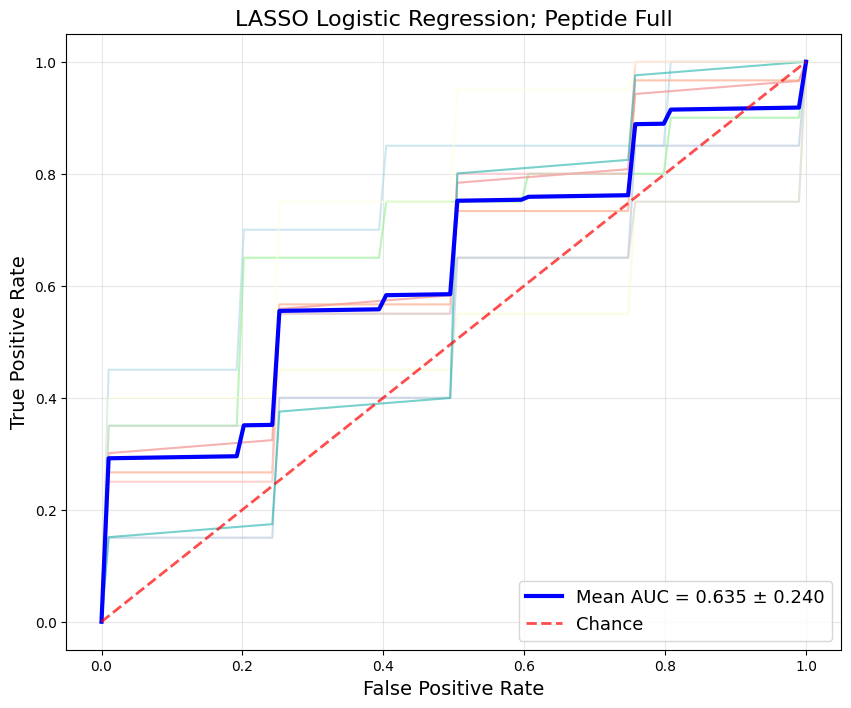

In [ ]:
# For unfiltered results
#plot_mean_roc_per_fold(cv_results, dataset_name=DATASET_NAME, n_splits=10, use_volcano=False)


# For filtered results
plot_mean_roc_per_fold(cv_results, dataset_name=DATASET_NAME, n_splits=10)

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42   # keep text as editable text
mpl.rcParams['ps.fonttype'] = 42    # same for EPS (if ever used)

plt.savefig(
    f"ROC_{DATASET_NAME}.pdf",
    format="pdf",
    bbox_inches="tight"   # trims whitespace
    # dpi optional or unnecessary
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_feature_importance_with_freq(cv_results, top_n=20, dataset_name="Dataset"):
    """
    Plot feature importance across CV folds as horizontal barplots of:
    1. Mean absolute coefficients with standard error
    2. Feature selection frequency across folds
    Works with scikit-learn Pipelines.
    """

    # --- Step 1: Collect all features across folds ---
    all_features = set()
    for fold in cv_results:
        model = fold['final_model']
        # Access feature names from the pipeline's model step
        if hasattr(model.named_steps['model'], 'coef_'):
            n_features = model.named_steps['model'].coef_.shape[1]
            if hasattr(model, 'feature_names_in_'):
                all_features.update(model.feature_names_in_)
            else:
                all_features.update([f'feature_{i}' for i in range(n_features)])
    all_features = list(all_features)
    if len(all_features) == 0:
        print("No features found across folds! Cannot plot feature importance.")
        return

    # --- Step 2: Collect coefficients and selection flags ---
    coefs_all_folds = []
    selected_flags = []

    for fold in cv_results:
        model = fold['final_model']
        logreg = model.named_steps['model']  # Access LogisticRegression step
        model_features = list(model.feature_names_in_) if hasattr(model, 'feature_names_in_') else [f'feature_{i}' for i in range(logreg.coef_.shape[1])]
        coefs = np.zeros(len(all_features))
        selection_flag = np.zeros(len(all_features))
        for i, feature in enumerate(all_features):
            if feature in model_features:
                idx = model_features.index(feature)
                coefs[i] = abs(logreg.coef_[0][idx])
                selection_flag[i] = 1 if coefs[i] > 1e-6 else 0
        coefs_all_folds.append(coefs)
        selected_flags.append(selection_flag)

    coefs_all_folds = np.array(coefs_all_folds)
    selected_flags = np.array(selected_flags)

    # --- Step 3: Compute mean and standard error ---
    mean_coef = np.mean(coefs_all_folds, axis=0)
    stderr_coef = np.std(coefs_all_folds, axis=0) / np.sqrt(coefs_all_folds.shape[0])

    fimp_df = pd.DataFrame({
        "mean_importance": mean_coef,
        "stderr": stderr_coef
    }, index=all_features)

    # Get top features
    top_features_df = fimp_df[fimp_df["mean_importance"] > 1e-6].sort_values("mean_importance", ascending=False).head(top_n)
    top_feature_names = top_features_df.index.tolist()
    top_indices = [all_features.index(f) for f in top_feature_names]

    # --- Plot 1: Mean Absolute Coefficients ---
    plt.figure(figsize=(13, 9))
    means = top_features_df["mean_importance"].values
    std_errors_vals = top_features_df["stderr"].values
    plt.barh(top_feature_names, means, xerr=std_errors_vals,
              color=plt.cm.turbo_r(np.linspace(0, 1, len(top_feature_names))),
             alpha=0.7, capsize=5)
    plt.xlabel("Mean Absolute Coefficient", fontsize=14)
    plt.title(f"Feature Importance LASSO ; {dataset_name}", fontsize=16, loc='center')
    plt.gca().invert_yaxis()  # highest feature on top



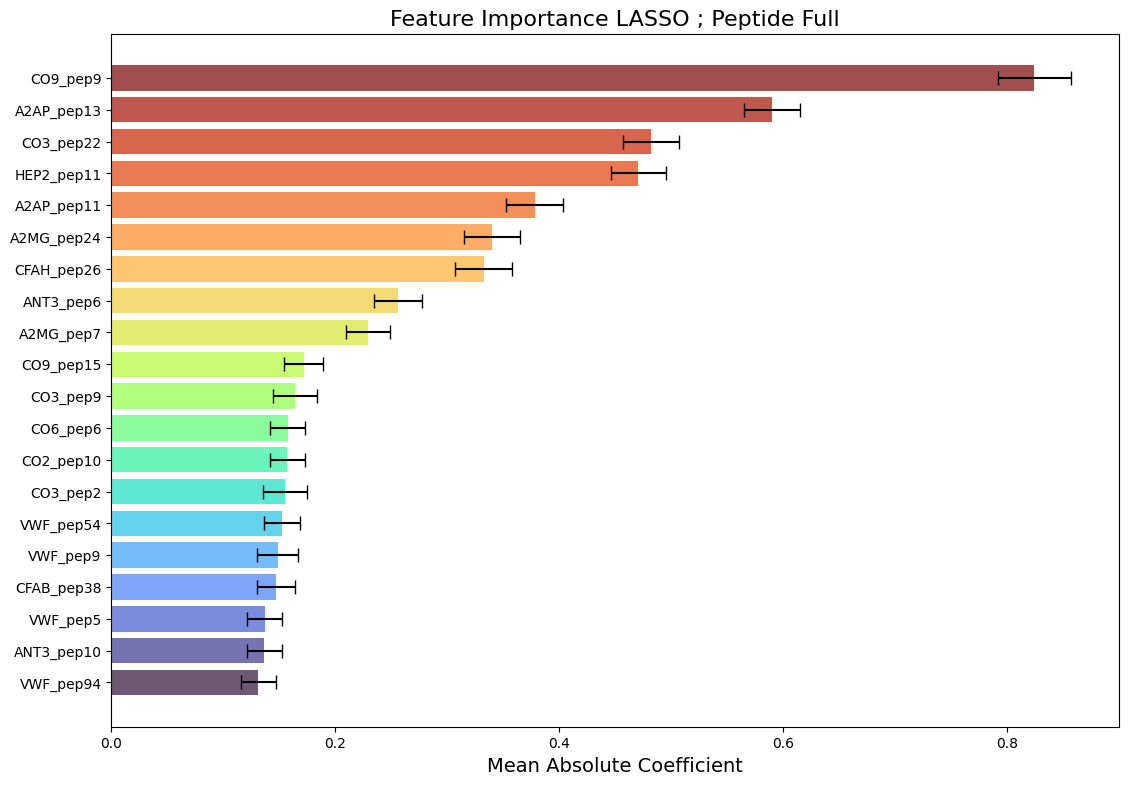

In [ ]:
# For unfiltered results
#plot_feature_importance_with_freq(cv_results, top_n=20, dataset_name=DATASET_NAME)

# For filtered results
plot_feature_importance_with_freq(cv_results, top_n=20, dataset_name=DATASET_NAME)

mpl.rcParams['pdf.fonttype'] = 42   # keep text editable
mpl.rcParams['ps.fonttype'] = 42


# GLM


In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
# from scipy import stats
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve, auc as auc_score, confusion_matrix
# from joblib import Parallel, delayed
# import statsmodels.api as sm

# # --- Your existing CV setup ---

# k_prot = 10

# cv_results = []

# DATASET_NAME = "Clinical Data"  # Can be "PEPTIDE", "CLINICAL", etc.
# USE_VOLCANO = False  # Enable volcano filtering (chi2 or t-test depending on dataset)

# # Select dataset and CV splitter (example variables - replace with your data)
# if DATASET_NAME == "Protein Full":
#     X_data, y_data, skf_data, k_splits = X_prot, y_prot, skf_prot, k_prot
# elif DATASET_NAME == "Peptide Full":
#     X_data, y_data, skf_data, k_splits = X_filt_pep, y_pep, skf_pep, k_pep
# elif DATASET_NAME == "Clinical Data":
#     X_data, y_data, skf_data, k_splits = X_filt_clin, y_clin, skf_clin, k_clin
# elif DATASET_NAME == "Protein & Clinical Data":
#     X_data, y_data, skf_data, k_splits = X_filt_prot_comb, y_prot_comb, skf_prot, k_prot
# elif DATASET_NAME == "Peptide & Clinical Data":
#     X_data, y_data, skf_data, k_splits = X_filt_pep_comb, y_pep_comb, skf_pep, k_pep

# print(f"=== {DATASET_NAME} DATA CROSS-VALIDATION PIPELINE ===")
# print(f"Volcano filtering: {'ENABLED' if USE_VOLCANO else 'DISABLED'}")

# # Fixed fold numbering - track repetitions and folds properly
# total_iterations = 0
# for train_idx, test_idx in skf_data.split(X_data, y_data):

#     # Calculate current repetition and fold
#     current_repetition = (total_iterations // k_splits) + 1
#     current_fold = (total_iterations % k_splits) + 1

#     print(f"\n{'='*80}")
#     print(f"--- REPETITION {current_repetition}, FOLD {current_fold}/{k_splits} ---")
#     print(f"{'='*80}")

#     X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
#     y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]

#     print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

#     # Volcano filtering applied only if USE_VOLCANO is True
#     if USE_VOLCANO:
#         print("Performing volcano analysis...")
#         selected_features = volcano_analysis(X_train, y_train, dataset_name=DATASET_NAME)

#         if len(selected_features) == 0:
#             print("No features selected by volcano/chi2 filtering. Falling back to top 50 by variance.")
#             feature_variances = X_train.var()
#             selected_features = feature_variances.nlargest(50).index.tolist()

#         X_train_reduced = X_train[selected_features]
#         X_test_reduced = X_test[selected_features]

#         print(f"Selected {len(selected_features)} features.")
#         print(f"Reduced training set shape: {X_train_reduced.shape}")

#     else:
#         print("Skipping volcano analysis - using all features.")
#         X_train_reduced = X_train
#         X_test_reduced = X_test
#         selected_features = X_train.columns.tolist()
#         print(f"Using all {len(selected_features)} features.")

#     # Hyperparameter tuning with nested CV (inner 3-fold)
#     param_grid = {'C': [0.01, 0.1, 1, 10]}

#     inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#     lasso_logistic = LogisticRegression(
#         penalty='l1',
#         solver='liblinear',
#         random_state=42,
#         max_iter=1000
#     )

#     grid_search = GridSearchCV(
#         lasso_logistic,
#         param_grid,
#         cv=inner_cv,
#         scoring='roc_auc',
#         n_jobs=-1
#     )

#     grid_search.fit(X_train_reduced, y_train)

#     best_C = grid_search.best_params_['C']
#     print(f"Best regularization parameter C: {best_C}")
#     print(f"Best CV score: {grid_search.best_score_:.4f}")

#     # Fit final LASSO model on full training subset with best hyperparameter
#     final_model = LogisticRegression(
#         penalty='l1',
#         solver='liblinear',
#         C=best_C,
#         random_state=42,
#         max_iter=1000,
#         class_weight='balanced'
#     )

#     final_model.fit(X_train_reduced, y_train)

#     # =========================
#     # LASSO feature selection
#     # =========================

#     coef = final_model.coef_.ravel()
#     lasso_selected_idx = np.where(coef != 0)[0]
#     lasso_selected_features = X_train_reduced.columns[lasso_selected_idx].tolist()
#     lasso_coefs = coef[lasso_selected_idx]

#     print(f"\nLASSO selected {len(lasso_selected_features)} features:")
#     print(lasso_selected_features)

#     # =========================
#     # Unpenalised GLM for inference
#     # =========================

#     glm_result = None
#     glm_table = None

#     if len(lasso_selected_features) > 0:

#         # Extract LASSO-selected features
#         X_glm = X_train_reduced[lasso_selected_features].copy()

#         # Force all columns to numeric
#         X_glm = X_glm.apply(pd.to_numeric, errors='coerce')

#         # Drop rows with missing values (GLM cannot handle NaNs)
#         valid_idx = X_glm.notnull().all(axis=1)

#         print(f"Rows before NaN removal: {len(X_glm)}")
#         print(f"Rows after NaN removal: {valid_idx.sum()}")

#         X_glm = X_glm.loc[valid_idx]
#         y_glm = y_train.loc[valid_idx]

#         # Add intercept
#         X_glm = sm.add_constant(X_glm)

#         try:
#             print(f"\nFitting GLM with {X_glm.shape[0]} samples and {X_glm.shape[1]-1} features...")

#             glm_model = sm.Logit(y_glm, X_glm)
#             glm_result = glm_model.fit(disp=False)

#             print("\n" + "="*80)
#             print("GLM (unpenalised) summary:")
#             print("="*80)
#             print(glm_result.summary())

#             # Extract coefficient table
#             glm_table = glm_result.summary2().tables[1]

#             # Create detailed results dataframe
#             glm_stats = pd.DataFrame({
#                 'Feature': glm_result.params.index,
#                 'GLM_Coefficient': glm_result.params.values,
#                 'Std_Error': glm_result.bse.values,
#                 'P_Value': glm_result.pvalues.values
#             })

#             # Add LASSO coefficients for comparison
#             lasso_coef_dict = dict(zip(lasso_selected_features, lasso_coefs))
#             glm_stats['LASSO_Coefficient'] = glm_stats['Feature'].map(lasso_coef_dict)

#             # Calculate difference
#             glm_stats['Difference'] = glm_stats['GLM_Coefficient'] - glm_stats['LASSO_Coefficient']
#             glm_stats['Significant'] = glm_stats['P_Value'] < 0.05

#             print("\n" + "="*80)
#             print("LASSO vs GLM COEFFICIENT COMPARISON")
#             print("="*80)
#             print(glm_stats[glm_stats['Feature'] != 'const'].sort_values('P_Value'))

#         except Exception as e:
#             print(f"GLM failed due to: {e}")
#             import traceback
#             traceback.print_exc()

#     else:
#         print("No variables selected by LASSO — skipping GLM.")

#     # Predictions and evaluation on test set (LASSO model)
#     y_pred = final_model.predict(X_test_reduced)
#     y_pred_proba = final_model.predict_proba(X_test_reduced)[:, 1]

#     accuracy = accuracy_score(y_test, y_pred)
#     fold_auc = roc_auc_score(y_test, y_pred_proba)

#     print(f"\nLASSO Test Accuracy: {accuracy:.4f}")
#     print(f"LASSO Test AUC: {fold_auc:.4f}")

#     fold_results = {
#         'repetition': current_repetition,
#         'fold': current_fold,
#         'total_iteration': total_iterations + 1,
#         'n_features_selected': len(lasso_selected_features),
#         'best_C': best_C,
#         'best_cv_score': grid_search.best_score_,
#         'test_accuracy': accuracy,
#         'test_auc': fold_auc,
#         'y_test': y_test,
#         'y_pred': y_pred,
#         'y_pred_proba': y_pred_proba,
#         'final_model': final_model,
#         'lasso_selected_features': lasso_selected_features,
#         'lasso_coefs': lasso_coefs,
#         'glm_result': glm_result,
#         'glm_table': glm_table
#     }

#     cv_results.append(fold_results)
#     total_iterations += 1

# # =========================
# # CV SUMMARY
# # =========================

# print("\n" + "="*80)
# print("=== CROSS-VALIDATION SUMMARY ===")
# print("="*80)
# results_df = pd.DataFrame(cv_results)
# print(results_df[['repetition', 'fold', 'total_iteration', 'test_accuracy', 'test_auc', 'n_features_selected']])

# print(f"\nMean Test Accuracy: {results_df['test_accuracy'].mean():.4f} ± {results_df['test_accuracy'].std():.4f}")
# print(f"Mean Test AUC: {results_df['test_auc'].mean():.4f} ± {results_df['test_auc'].std():.4f}")
# print(f"Mean Features Selected: {results_df['n_features_selected'].mean():.1f}")

# # Compute mean sensitivity and specificity across folds
# sensitivities = []
# specificities = []

# for fold in cv_results:
#     tn, fp, fn, tp = confusion_matrix(fold['y_test'], fold['y_pred']).ravel()
#     sens = tp / (tp + fn) if (tp + fn) > 0 else 0
#     spec = tn / (tn + fp) if (tn + fp) > 0 else 0
#     sensitivities.append(sens)
#     specificities.append(spec)

# sensitivities = np.array(sensitivities)
# specificities = np.array(specificities)

# print(f"Mean Sensitivity: {sensitivities.mean():.4f} ± {sensitivities.std():.4f}")
# print(f"Mean Specificity: {specificities.mean():.4f} ± {specificities.std():.4f}")

# # =========================
# # LASSO vs GLM COMPARISON ACROSS ALL FOLDS
# # =========================

# print("\n" + "="*80)
# print("=== LASSO vs GLM COMPARISON (AGGREGATED ACROSS FOLDS) ===")
# print("="*80)

# # Collect LASSO coefficients
# lasso_coefs_all = []
# for fold in cv_results:
#     for feat, coef in zip(fold['lasso_selected_features'], fold['lasso_coefs']):
#         lasso_coefs_all.append({'Feature': feat, 'LASSO_Coef': coef})

# lasso_df = pd.DataFrame(lasso_coefs_all)
# lasso_summary = lasso_df.groupby('Feature')['LASSO_Coef'].mean().to_frame()
# lasso_summary.columns = ['Mean_LASSO_Coef']

# # Collect GLM coefficients
# glm_tables = [fold['glm_table'] for fold in cv_results if fold['glm_table'] is not None]

# if len(glm_tables) > 0:
#     glm_df = pd.concat(glm_tables, axis=0).reset_index()
#     glm_df = glm_df.rename(columns={'index': 'Feature'})

#     glm_summary = (
#         glm_df
#         .assign(significant=lambda df: df['P>|z|'] < 0.05)
#         .groupby('Feature')
#         .agg(
#             Mean_GLM_Coef=('Coef.', 'mean'),
#             Mean_Std_Error=('Std.Err.', 'mean'),
#             Mean_P_Value=('P>|z|', 'mean'),
#             Prop_Significant=('significant', 'mean')
#         )
#     )

#     # Combine LASSO and GLM results
#     comparison = lasso_summary.join(glm_summary, how='outer')
#     comparison = comparison[comparison.index != 'const']
#     comparison['Coef_Difference'] = comparison['Mean_GLM_Coef'] - comparison['Mean_LASSO_Coef']
#     comparison = comparison.sort_values('Prop_Significant', ascending=False)

#     print(comparison)

#     print("\n" + "="*80)
#     print("SUMMARY")
#     print("="*80)
#     print(f"Total features: {len(comparison)}")
#     print(f"Features significant in >50% of folds: {(comparison['Prop_Significant'] > 0.5).sum()}")
#     print(f"Mean absolute coefficient difference (GLM - LASSO): {comparison['Coef_Difference'].abs().mean():.4f}")

#     results_df_clinical = results_df.copy()
#     clinical_comparison = comparison.copy()
# else:
#     print("No GLM results available")